In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('linear_regression.csv')

In [ ]:
df.head()

,x,y
0,24,21.549452
1,50,47.464463
2,15,17.218656
3,38,36.586398
4,87,87.288984


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       700 non-null    int64  
 1   y       700 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 11.1 KB


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df[['x']], df['y'], test_size=0.2, random_state=42)

<Axes: title={'center': 'Data visualisation'}, xlabel='x', ylabel='y'>

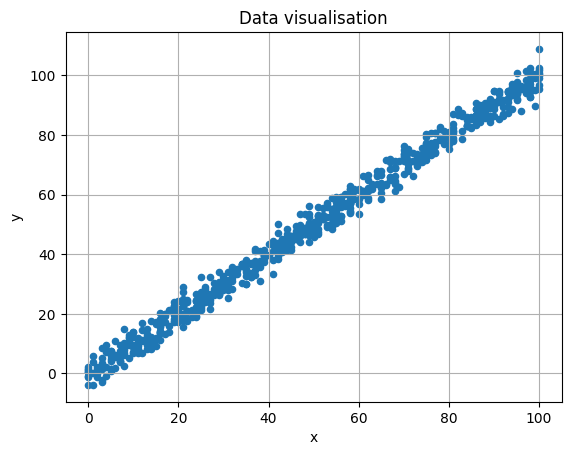

In [ ]:
df.plot.scatter(x='x', y='y', xlabel='x', ylabel='y', title='Data visualisation', grid=True)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
reg = LinearRegression().fit(X_train, y_train)

In [ ]:
reg.coef_

array([1.00089617])

In [ ]:
reg.intercept_

np.float64(-0.14006817009452277)

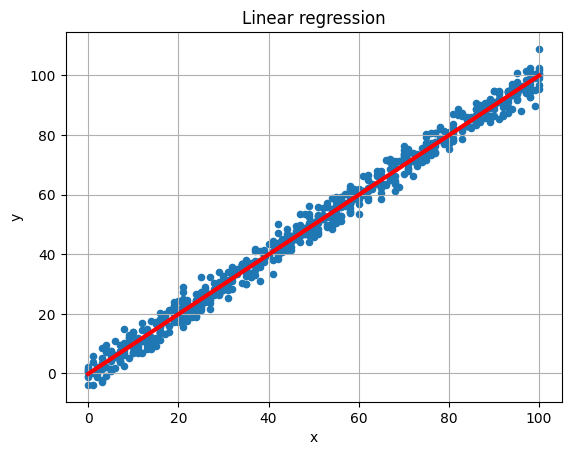

In [ ]:
df.plot.scatter(x='x', y='y', xlabel='x', ylabel='y', title='Linear regression', grid=True)
plt.plot([0, 100], [0*reg.coef_[0]+reg.intercept_, 100*reg.coef_[0]+reg.intercept_], color='red', linewidth=3)

In [ ]:
print('Train:', reg.score(X_train, y_train))
print('Test:', reg.score(X_test, y_test))

Train: 0.990380796581592
Test: 0.9915260812752268


In [ ]:
from sklearn.metrics import mean_squared_error as MSE

In [ ]:
print('MSE:', MSE(reg.predict(X_test), y_test))
print('RMSE:', MSE(reg.predict(X_test), y_test)**0.5)

MSE: 8.004011606213526
RMSE: 2.829136194355713


In [ ]:
from sklearn.metrics import r2_score

In [ ]:
print('R2:', r2_score(reg.predict(X_test), y_test))

R2: 0.9914583109695955


In [ ]:
from sklearn.metrics import mean_absolute_error as MAE, mean_absolute_percentage_error as MAPE

In [ ]:
print('MAE:', MAE(reg.predict(X_test), y_test))
print('MAPE:', MAPE(reg.predict(X_test), y_test))

MAE: 2.263741325510488
MAPE: 0.2802113257816474


In [ ]:
import numpy as np
from sklearn.metrics import (median_absolute_error, max_error)

Другие оценки:


---


MedAE - медиана абсолютных ошибок, устойчива к выбросам.

---


Max Error - максимальная абсолютная ошибка.

In [ ]:
medae = median_absolute_error(reg.predict(X_test), y_test)
max_err = max_error(reg.predict(X_test), y_test)
print(f'MedAE: {medae}', f'Max Error: {max_err}', sep='\n')

MedAE: 1.9995628045934684
Max Error: 8.02385073484595


Доля предсказаний с абсолютными ошибками больше некоторого значения(>1)

In [ ]:
threshold = 1
abs_errors = np.abs(y_test - reg.predict(X_test))
error_rate = np.mean(abs_errors > threshold)

print(f'\nДоля ошибок>{threshold}: {error_rate}')


Доля ошибок>1: 0.7071428571428572


In [ ]:
df = pd.read_csv('insurance.csv')

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


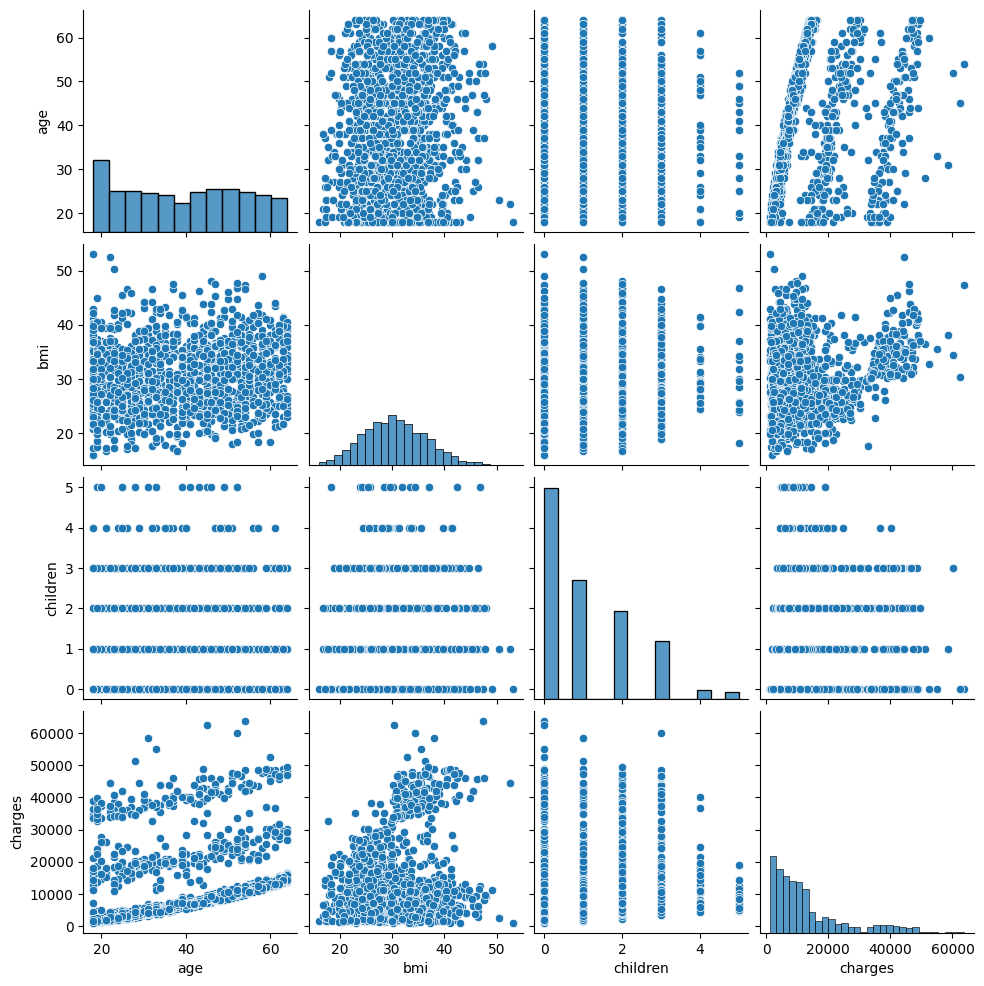

In [ ]:
sns.pairplot(df)

In [ ]:
sns.heatmap(df.corr(), cmap='bwr', center=0, annot=True)

ValueError: could not convert string to float: 'female'

In [ ]:
df['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [ ]:
df['smoker'] = df['smoker'].apply(lambda x: 0 if x=='no' else 1)

In [ ]:
df['smoker'].unique()

array([1, 0])

In [ ]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [ ]:
df['sex'] = df['sex'].apply(lambda x: 0 if x=='male' else 1)

In [ ]:
df['sex'].unique()

array([1, 0])

In [ ]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [ ]:
pd.get_dummies(df['region']).head()

,northeast,northwest,southeast,southwest
0,False,False,False,True
1,False,False,True,False
2,False,False,True,False
3,False,True,False,False
4,False,True,False,False


In [ ]:
pd.get_dummies(df['region'], drop_first=True).head()

,northwest,southeast,southwest
0,False,False,True
1,False,True,False
2,False,True,False
3,True,False,False
4,True,False,False


In [ ]:
df = pd.read_csv('insurance.csv')

In [ ]:
pd.get_dummies(df, drop_first=True).head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
df = pd.read_csv('insurance.csv')

In [ ]:
encoder = OrdinalEncoder()
data_ordinal = pd.DataFrame(encoder.fit_transform(df), columns=df.columns)

In [ ]:
data_ordinal.head()

,age,sex,bmi,children,smoker,region,charges
0,1.0,0.0,197.0,0.0,1.0,3.0,1005.0
1,0.0,1.0,350.0,1.0,0.0,2.0,57.0
2,10.0,1.0,331.0,3.0,0.0,2.0,306.0
3,15.0,1.0,73.0,0.0,0.0,1.0,1097.0
4,14.0,1.0,223.0,0.0,0.0,1.0,254.0


In [ ]:
df = pd.read_csv('insurance.csv')

In [ ]:
df = pd.get_dummies(df, drop_first=True)

Использована техника прямого кодирования, т.к. не все данные категориальные

In [ ]:
df

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


<Axes: >

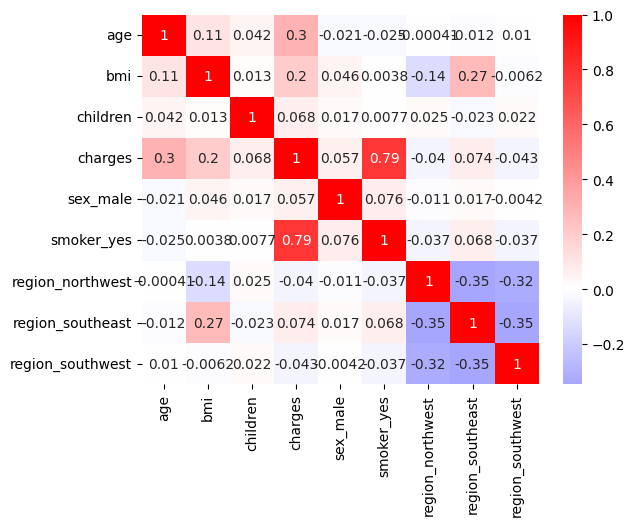

In [ ]:
sns.heatmap(df.corr(), cmap='bwr', center=0, annot=True)

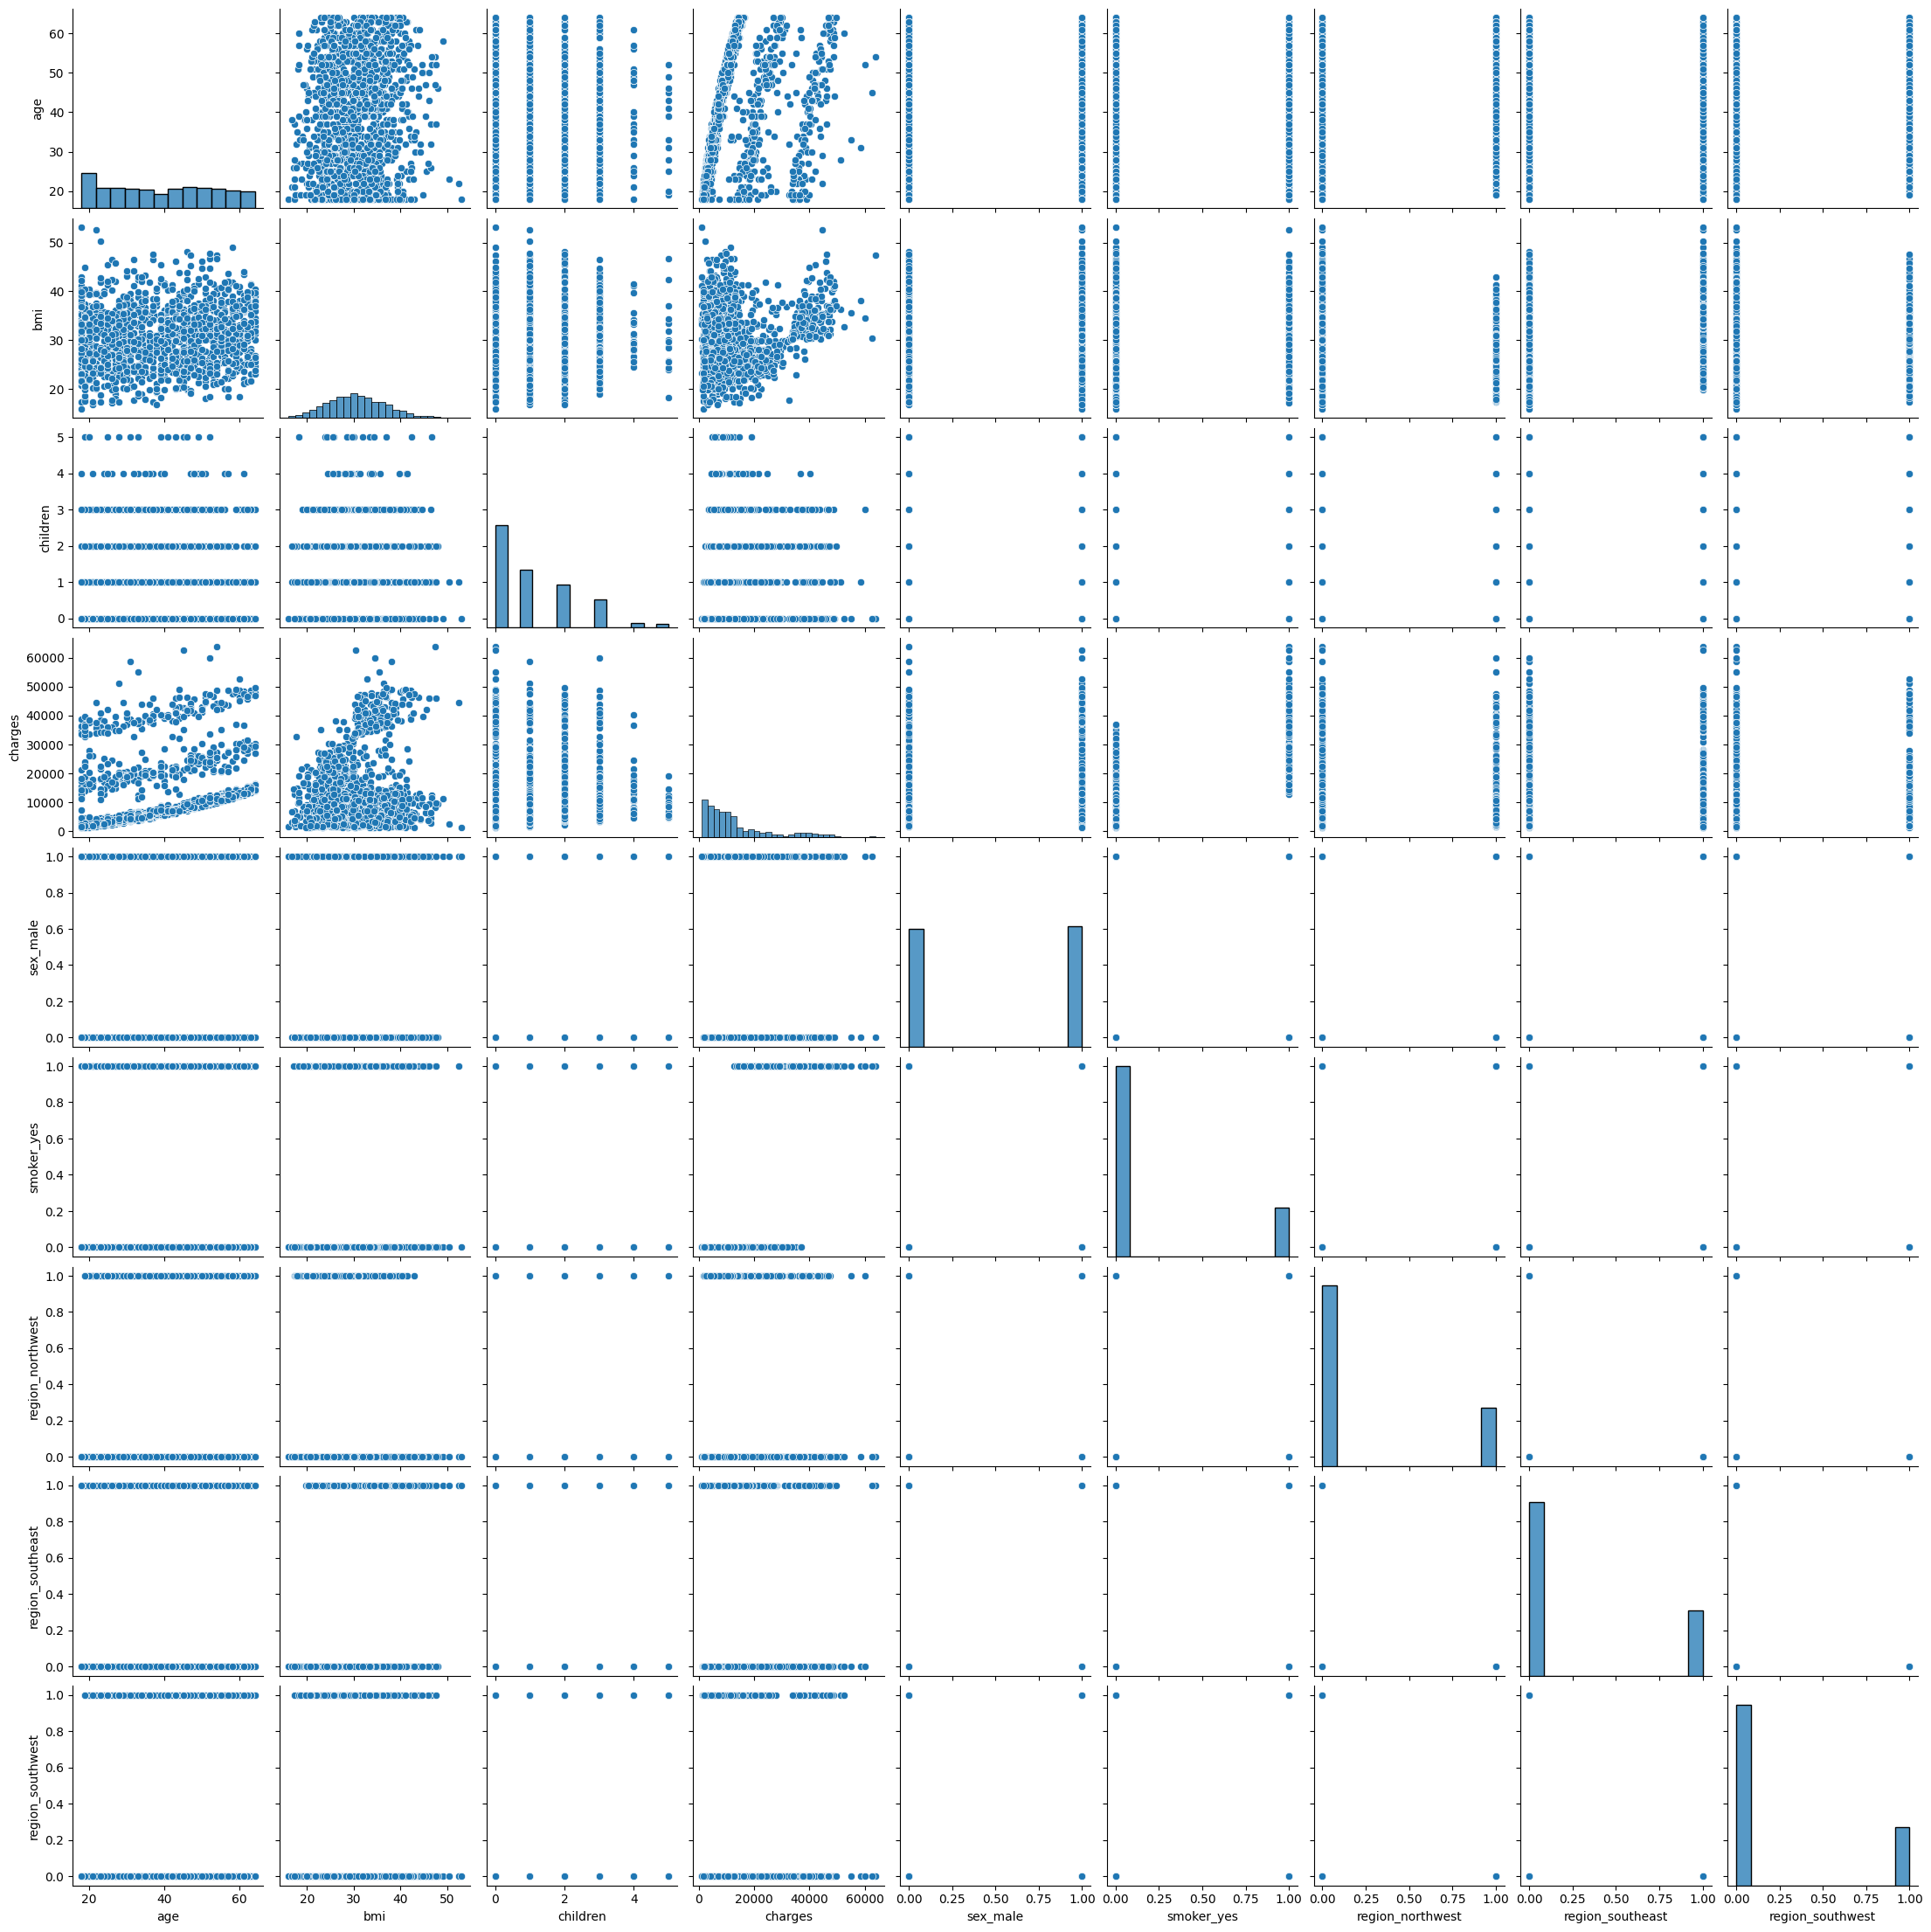

In [ ]:
sns.pairplot(df)

In [ ]:
features = df.drop(columns=['charges'])
target = df['charges']
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
reg = LinearRegression().fit(X_train, y_train)

In [ ]:
reg.score(features, target)

0.7506500728231758

In [ ]:
reg.coef_

array([ 2.56975706e+02,  3.37092552e+02,  4.25278784e+02, -1.85916916e+01,
        2.36511289e+04, -3.70677326e+02, -6.57864297e+02, -8.09799354e+02])

In [ ]:
reg.intercept_

np.float64(-11931.21905032666)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   bmi               1338 non-null   float64
 2   children          1338 non-null   int64  
 3   charges           1338 non-null   float64
 4   sex_male          1338 non-null   bool   
 5   smoker_yes        1338 non-null   bool   
 6   region_northwest  1338 non-null   bool   
 7   region_southeast  1338 non-null   bool   
 8   region_southwest  1338 non-null   bool   
dtypes: bool(5), float64(2), int64(2)
memory usage: 48.5 KB


In [ ]:
bool_columns = ['sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
df[bool_columns] = df[bool_columns].astype(int)

In [ ]:
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [ ]:
import statsmodels.api as sm

In [ ]:
features = df.drop(columns=['charges'])
target = df['charges']

In [ ]:
features = sm.add_constant(features)

In [ ]:
model = sm.OLS(target, features)

In [ ]:
results = model.fit()

In [ ]:
results.params

,0
const,-11938.538576
age,256.856353
bmi,339.193454
children,475.500545
sex_male,-131.314359
smoker_yes,23848.534542
region_northwest,-352.963899
region_southeast,-1035.022049
region_southwest,-960.050991


Коэффициенты в среднем отличаются на пару десятков

In [ ]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Fri, 23 May 2025   Prob (F-statistic):               0.00
Time:                        17:46:11   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819    -12.086      0.000   -1.39e+04      -1e+04
age                256.8564     11.899     21.587      0.000     233.514     280.199
bmi                339.1935     28.599     11.860      0.000     283.088     395.298
children           475.5005    137.804      3.451      0.001     205.163     745.838
sex_male          -131.3144    332.945     -0.394      0.693    -784.470     521.842
smoker_yes        2.385e+04    413.153     57.723      0.000     2.3e+04    2.47e+04
region_northwest  -352.9639    476.276     -0.741      0.459   -1287.298     581.370
region_southeast -1035.0220    478.692     -2.162      0.031   -1974.097     -95.947
region_southwest  -960.0510    477.933     -2.009      0.045   -1897.636     -22.466
==============================================================================
Omnibus:                      300.366   Durbin-Watson:                   2.088
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              718.887
Skew:                           1.211   Prob(JB):                    7.86e-157
Kurtosis:                       5.651   Cond. No.                         311.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
features = df.drop(columns=['charges', 'sex_male', 'region_northwest', 'region_southwest'])
target = df['charges']

In [ ]:
features = sm.add_constant(features)

In [ ]:
model = sm.OLS(target, features)

In [ ]:
results = model.fit()
results.params

,0
const,-12275.597021
age,257.136536
bmi,333.444786
children,468.066786
smoker_yes,23853.972753
region_southeast,-578.861988


In [ ]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     799.7
Date:                Fri, 23 May 2025   Prob (F-statistic):               0.00
Time:                        18:07:00   Log-Likelihood:                -13550.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1332   BIC:                         2.714e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.228e+04    948.666    -12.940      0.000   -1.41e+04   -1.04e+04
age                257.1365     11.901     21.607      0.000     233.791     280.482
bmi                333.4448     28.449     11.721      0.000     277.635     389.255
children           468.0668    137.777      3.397      0.001     197.783     738.350
smoker_yes        2.385e+04    412.023     57.895      0.000     2.3e+04    2.47e+04
region_southeast  -578.8620    388.384     -1.490      0.136   -1340.774     183.050
==============================================================================
Omnibus:                      302.906   Durbin-Watson:                   2.089
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              726.891
Skew:                           1.220   Prob(JB):                    1.44e-158
Kurtosis:                       5.662   Cond. No.                         294.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Коэффициенты немного увеличились